# Exact filler-token sweep before `FINAL: `

This is the no-thinking successor to notebook 05. The public game,
raw reports, and candidates 2 versus 7 are unchanged. The assistant
prefix is constructed at token-ID level as
`chat_prefix + [filler_id] * F + tokenize("FINAL: ")`, and the next
token is scored only over `2`, `7`, and `=`. There is no generated
scratchpad and no reasoning-length instruction.

The full `F = 0..100` sweep over five single-token fillers is the
development split. Before looking at a repeat, the selection rule was
frozen: choose the filler with highest mean candidate-only accuracy,
then its smallest maximizer of a centered five-point moving average.
Exactly that one condition is evaluated once on repeat 1.


In [1]:
from __future__ import annotations

import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook inside the MATS repository.")


def load_jsonl(path: Path) -> list[dict[str, object]]:
    return [json.loads(line) for line in path.read_text().splitlines() if line.strip()]


REPO_ROOT = find_repo_root()
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "filler_token_probe"
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
dev_path = ARTIFACT_DIR / "development_all_fillers_results.jsonl"
dev_manifest_path = ARTIFACT_DIR / "development_all_fillers_manifest.json"
val_path = ARTIFACT_DIR / "validation_selected_results.jsonl"
val_manifest_path = ARTIFACT_DIR / "validation_selected_manifest.json"

dev = load_jsonl(dev_path)
val = load_jsonl(val_path)
dev_manifest = json.loads(dev_manifest_path.read_text())
val_manifest = json.loads(val_manifest_path.read_text())
conditions = dev_manifest["summary"]["conditions"]

fillers = sorted(dev_manifest["protocol"]["fillers"])
expected_fillers = ["comma", "newline", "period", "space", "underscore"]
assert fillers == expected_fillers
assert len(dev) == 56 * 101 * len(fillers) == 28_280
assert len(val) == 56
assert dev_manifest["protocol"]["enable_thinking"] is False
assert dev_manifest["protocol"]["generated_reasoning_tokens"] == 0
assert val_manifest["protocol"]["enable_thinking"] is False
assert dev_manifest["protocol"]["final_prefix"] == "FINAL: "
assert dev_manifest["protocol"]["final_prefix_token_ids"] == [95429, 25, 220]
assert dev_manifest["protocol"]["answer_token_ids"] == {"2": 17, "7": 22, "=": 28}
assert all(row["enable_thinking"] is False for row in dev + val)

cell_sizes = Counter((row["filler"], row["filler_count"]) for row in dev)
assert len(cell_sizes) == 5 * 101 and set(cell_sizes.values()) == {56}
for filler in fillers:
    assert {f for name, f in cell_sizes if name == filler} == set(range(101))
    for example_id in {row["example_id"] for row in dev}:
        group = sorted(
            (
                row for row in dev
                if row["filler"] == filler and row["example_id"] == example_id
            ),
            key=lambda row: row["filler_count"],
        )
        baseline = group[0]["input_token_count"]
        assert all(
            row["input_token_count"] == baseline + row["filler_count"]
            for row in group
        )

print("Token-exact contract and 505-cell coverage: PASS")
print("development rows:", len(dev), "validation rows:", len(val))
for name in fillers:
    spec = dev_manifest["protocol"]["fillers"][name]
    print(f"{name:10s} surface={spec['surface']!r:4s} token_id={spec['token_id']}")


Token-exact contract and 505-cell coverage: PASS
development rows: 28280 validation rows: 56
comma      surface=','  token_id=11
newline    surface='\n' token_id=198
period     surface='.'  token_id=13
space      surface=' '  token_id=220
underscore surface='_'  token_id=62


## Development sweep and frozen selection

Candidate-only accuracy excludes the normative tie cases; overall
accuracy includes them. The model never chose the single-token tie
answer in this experiment, so overall accuracy is necessarily lower.
The horizontal line marks chance for the two non-tie candidates.


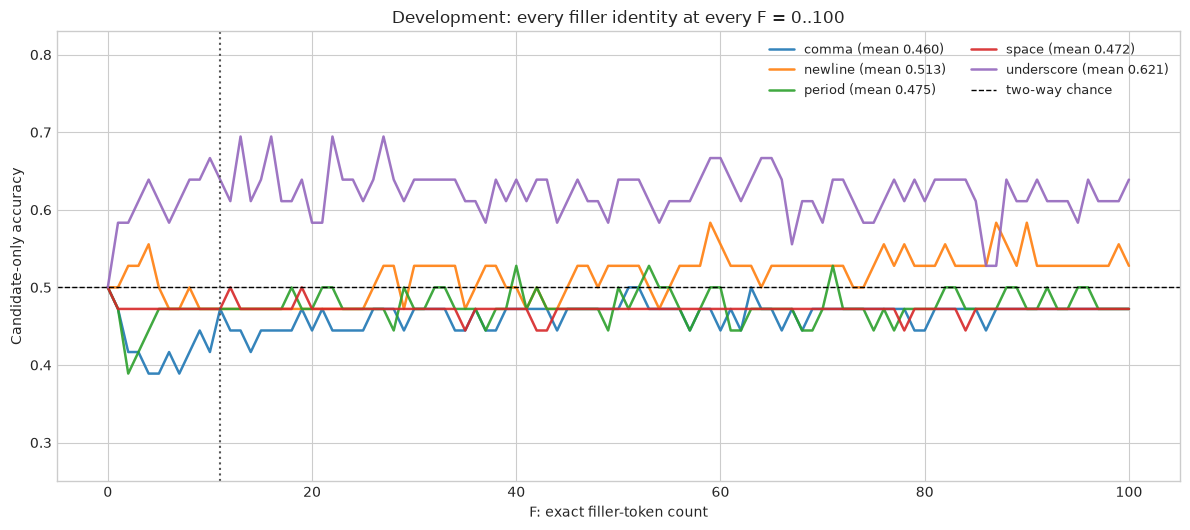

Frozen selection: underscore F = 11
five-point mean: 0.65


In [3]:
by_filler = {
    filler: sorted(
        (row for row in conditions if row["filler"] == filler),
        key=lambda row: row["filler_count"],
    )
    for filler in fillers
}
means = {
    filler: np.mean([row["candidate_only_accuracy"] for row in rows])
    for filler, rows in by_filler.items()
}
selected_filler = max(fillers, key=lambda filler: means[filler])
selected_curve = {
    row["filler_count"]: row["candidate_only_accuracy"]
    for row in by_filler[selected_filler]
}
smoothed = {
    f: np.mean([selected_curve[j] for j in range(f - 2, f + 3)])
    for f in range(2, 99)
}
best_smooth = max(smoothed.values())
selected_f = min(f for f, value in smoothed.items() if np.isclose(value, best_smooth))
assert (selected_filler, selected_f) == ("underscore", 11)

fig, ax = plt.subplots(figsize=(12, 5.4))
for filler, rows in by_filler.items():
    ax.plot(
        [row["filler_count"] for row in rows],
        [row["candidate_only_accuracy"] for row in rows],
        label=f"{filler} (mean {means[filler]:.3f})",
        alpha=0.9,
        linewidth=1.8,
    )
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="two-way chance")
ax.axvline(selected_f, color="#555555", linestyle=":", linewidth=1.5)
ax.set(xlabel="F: exact filler-token count", ylabel="Candidate-only accuracy",
       title="Development: every filler identity at every F = 0..100")
ax.set_ylim(0.25, 0.83)
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
figure_path = ARTIFACT_DIR / "exp1_filler_sweep.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print("Frozen selection:", selected_filler, "F =", selected_f)
print("five-point mean:", round(best_smooth, 4))


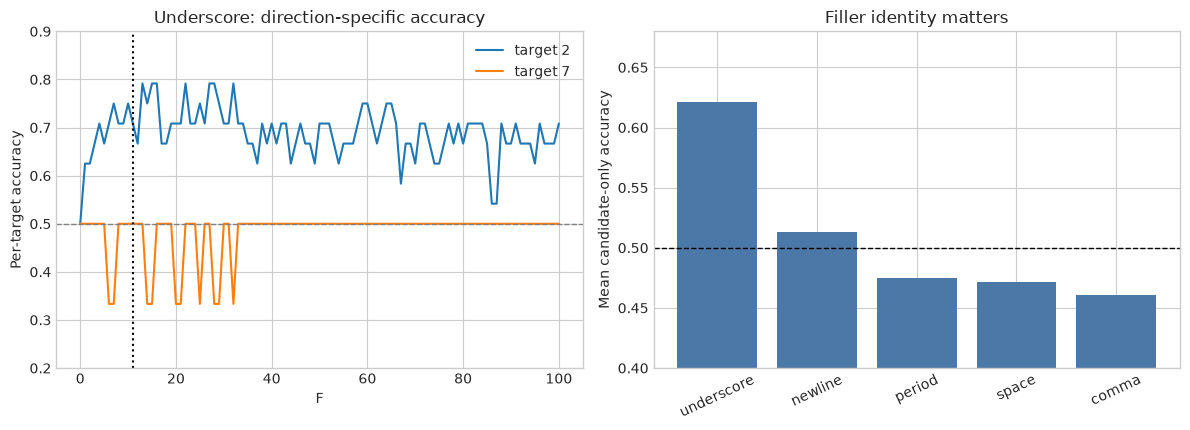

In [4]:
rows = by_filler[selected_filler]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].plot(
    [row["filler_count"] for row in rows],
    [row["candidate_2_accuracy"] for row in rows],
    label="target 2",
)
axes[0].plot(
    [row["filler_count"] for row in rows],
    [row["candidate_7_accuracy"] for row in rows],
    label="target 7",
)
axes[0].axvline(selected_f, color="black", linestyle=":")
axes[0].axhline(0.5, color="grey", linestyle="--", linewidth=1)
axes[0].set(
    xlabel="F",
    ylabel="Per-target accuracy",
    title="Underscore: direction-specific accuracy",
    ylim=(0.2, 0.9),
)
axes[0].legend()

order = sorted(fillers, key=means.get, reverse=True)
axes[1].bar(order, [means[name] for name in order], color="#4c78a8")
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].set(
    ylabel="Mean candidate-only accuracy",
    title="Filler identity matters",
    ylim=(0.4, 0.68),
)
axes[1].tick_params(axis="x", rotation=25)
fig.tight_layout()
figure_path = ARTIFACT_DIR / "exp1_selected_filler_bias.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()


## One-shot repeat-1 validation


In [5]:
dev_selected = next(
    row for row in conditions
    if row["filler"] == selected_filler and row["filler_count"] == selected_f
)
val_selected = val_manifest["summary"]["conditions"][0]
assert val_selected["filler"] == selected_filler
assert val_selected["filler_count"] == selected_f

print("metric                    development repeat 0    validation repeat 1")
for key in (
    "accuracy",
    "candidate_only_accuracy",
    "candidate_2_accuracy",
    "candidate_7_accuracy",
):
    print(f"{key:25s} {dev_selected[key]:20.3f} {val_selected[key]:22.3f}")
print("prediction counts         ", dev_selected["prediction_counts"],
      val_selected["prediction_counts"])


metric                    development repeat 0    validation repeat 1
accuracy                                 0.411                  0.446
candidate_only_accuracy                  0.639                  0.625
candidate_2_accuracy                     0.708                  0.600
candidate_7_accuracy                     0.500                  0.667
prediction counts          {'2': 42, '7': 14} {'2': 23, '7': 33}


## Interpretation

Exact filler tokens alter the immediate readout substantially:
underscore averages 0.621 candidate-only accuracy across all 101
lengths, versus 0.460–0.513 for the other identities. The frozen
underscore/F=11 condition validates at 0.625 candidate-only accuracy
(development 0.639). Its direction-specific validation recalls are
0.600 for candidate 2 and 0.667 for candidate 7, so the development
direction imbalance does not persist.

This is not evidence that silent filler tokens implement a faithful
reasoning trace. The model never predicts tie, and the sensitivity to
filler identity is itself a warning that the suffix changes the answer
readout. Experiment 3 tests that distinction causally.
